In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from scipy import stats

In [3]:
#LOAD DATASET
df = pd.read_csv("customer_churn.csv")

df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
#DATASET OVERVIEW
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


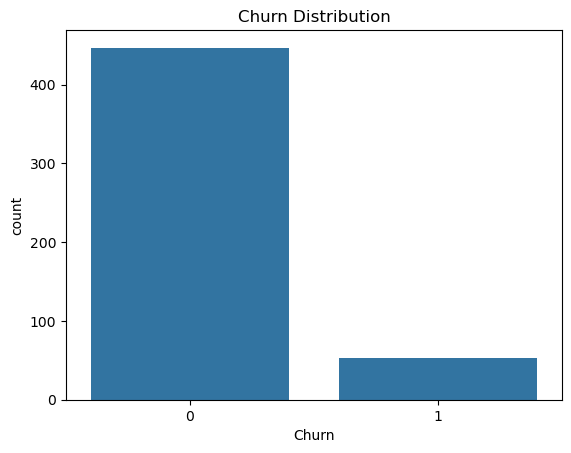

In [5]:
#CHECK CHURN DISTRIBUTION
sns.countplot(x='Churn', data=df)

plt.title("Churn Distribution")

plt.show()

In [6]:
#HANDLE MISSING VALUES
df.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [8]:
#ENCODING CATEGORICAL VARIABLES
#LABEL ENCODING
le = LabelEncoder()

df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

#ORDINAL ENCODING
ordinal_encoder = OrdinalEncoder()

df[['Contract']] = ordinal_encoder.fit_transform(df[['Contract']])

#ONE-HOT ENCODING
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=True)

In [11]:
#OUTLIER DETECTION
Q1 = df['MonthlyCharges'].quantile(0.25)

Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['MonthlyCharges'] >= lower) & (df['MonthlyCharges'] <= upper)]

print(df)

    CustomerID  Tenure  MonthlyCharges  TotalCharges  Contract  \
0       C00001       6              64          1540       1.0   
1       C00002      21             113          1753       0.0   
2       C00003      27              31          1455       2.0   
3       C00004      53              29          7150       0.0   
4       C00005      16             185          1023       1.0   
..         ...     ...             ...           ...       ...   
495     C00496      50             128          6970       0.0   
496     C00497       2              49          5917       2.0   
497     C00498      46             198          2158       0.0   
498     C00499       1             185          5755       2.0   
499     C00500      27             181          4292       0.0   

     PaperlessBilling  SeniorCitizen  Churn  PaymentMethod_Credit Card  \
0                   0              1      0                       True   
1                   1              1      0                

In [12]:
#Z-SCORE METHOD
z_scores = np.abs(stats.zscore(df[['MonthlyCharges','TotalCharges']]))

df = df[(z_scores < 3).all(axis=1)]
print(df)

    CustomerID  Tenure  MonthlyCharges  TotalCharges  Contract  \
0       C00001       6              64          1540       1.0   
1       C00002      21             113          1753       0.0   
2       C00003      27              31          1455       2.0   
3       C00004      53              29          7150       0.0   
4       C00005      16             185          1023       1.0   
..         ...     ...             ...           ...       ...   
495     C00496      50             128          6970       0.0   
496     C00497       2              49          5917       2.0   
497     C00498      46             198          2158       0.0   
498     C00499       1             185          5755       2.0   
499     C00500      27             181          4292       0.0   

     PaperlessBilling  SeniorCitizen  Churn  PaymentMethod_Credit Card  \
0                   0              1      0                       True   
1                   1              1      0                

In [14]:
#FEATURE ENGINEERING
# Customer Lifetime Value

df['CustomerLifetimeValue'] = df['MonthlyCharges'] * df['Tenure']


# Charges per tenure

df['ChargesPerTenure'] = df['TotalCharges'] / (df['Tenure'] + 1)


# Contract score

df['ContractScore'] = df['Contract'] * df['Tenure']


# Payment efficiency

df['PaymentEfficiency'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)


# Billing score

df['BillingScore'] = df['PaperlessBilling'] * df['Tenure']

print(df)

    CustomerID  Tenure  MonthlyCharges  TotalCharges  Contract  \
0       C00001       6              64          1540       1.0   
1       C00002      21             113          1753       0.0   
2       C00003      27              31          1455       2.0   
3       C00004      53              29          7150       0.0   
4       C00005      16             185          1023       1.0   
..         ...     ...             ...           ...       ...   
495     C00496      50             128          6970       0.0   
496     C00497       2              49          5917       2.0   
497     C00498      46             198          2158       0.0   
498     C00499       1             185          5755       2.0   
499     C00500      27             181          4292       0.0   

     PaperlessBilling  SeniorCitizen  Churn  PaymentMethod_Credit Card  \
0                   0              1      0                       True   
1                   1              1      0                

In [15]:
#MIN-MAX SCALING
scaler_minmax = MinMaxScaler()

df[['CustomerLifetimeValue','ChargesPerTenure']] = scaler_minmax.fit_transform(
    df[['CustomerLifetimeValue','ChargesPerTenure']]
)
print(df)

    CustomerID  Tenure  MonthlyCharges  TotalCharges  Contract  \
0       C00001       6              64          1540       1.0   
1       C00002      21             113          1753       0.0   
2       C00003      27              31          1455       2.0   
3       C00004      53              29          7150       0.0   
4       C00005      16             185          1023       1.0   
..         ...     ...             ...           ...       ...   
495     C00496      50             128          6970       0.0   
496     C00497       2              49          5917       2.0   
497     C00498      46             198          2158       0.0   
498     C00499       1             185          5755       2.0   
499     C00500      27             181          4292       0.0   

     PaperlessBilling  SeniorCitizen  Churn  PaymentMethod_Credit Card  \
0                   0              1      0                       True   
1                   1              1      0                

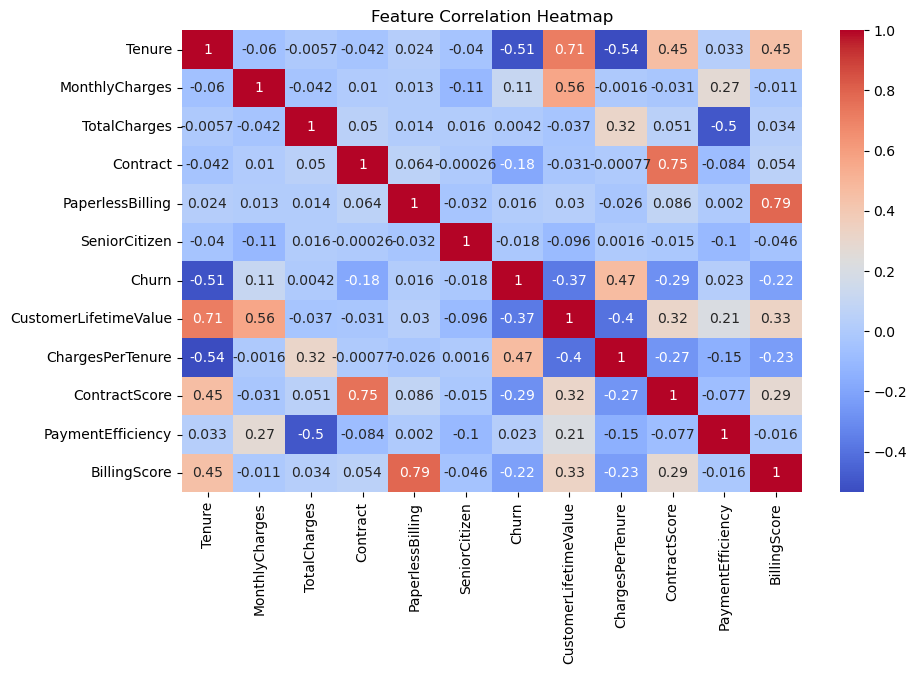

In [18]:
#FEATURE SELECTION
numeric_df = df.select_dtypes(include=['number'])

cor = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(cor, cmap='coolwarm', annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [19]:
#MODEL PREPERATION
X = df.drop(['CustomerID','Churn'], axis=1)

y = df['Churn']

In [20]:
#PREPROCESSING PIPELINE
numeric_features = ['Tenure','MonthlyCharges','TotalCharges']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

In [21]:
#FULL PIPELINE
pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier())
])

In [22]:
#TRAIN MODEL
pipeline.fit(X, y)

print("Pipeline training completed successfully")

Pipeline training completed successfully


In [24]:
# FEATURE IMPORTANCE

model = pipeline.named_steps['model']

importances = model.feature_importances_

# Get transformed feature names from pipeline
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

               Feature  Importance
0          num__Tenure    0.644618
2    num__TotalCharges    0.187499
1  num__MonthlyCharges    0.167883


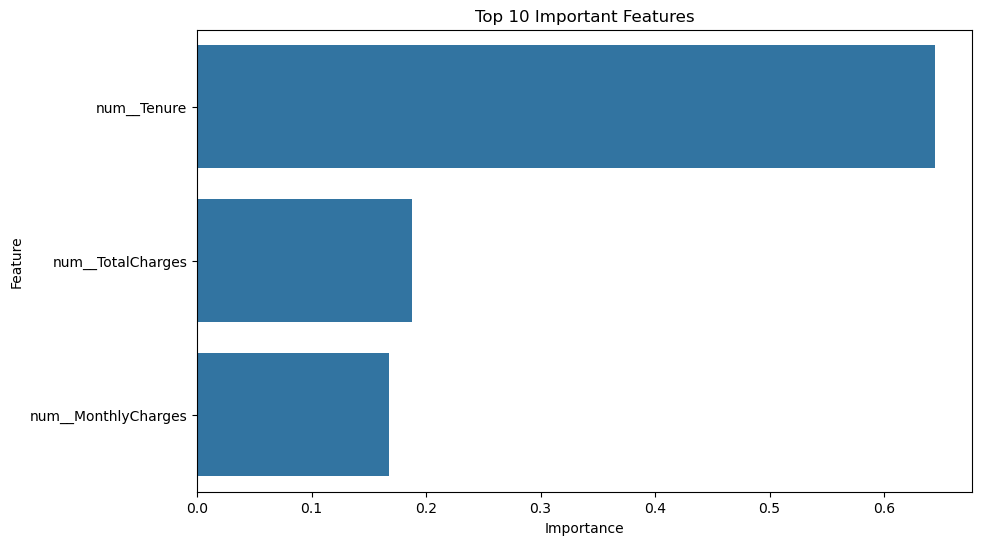

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()